In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [3]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [4]:
file_csv = '../../../../../../../data/phen/original/phenotypic_weather_obregon_151617_fifteen.csv'
print(os.getcwd())
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PCA,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

/phen/app/notebooks/phen/pca/phenotypic_weather/svr/fifteen


Launched SVR

In [5]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [6]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [7]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 43.65641208124417
R2 -> 0.8021295353990261
MAPE -> 0.05572453420686856


{'d2_absolute_error_score': 0.5340467324346754,
 'd2_pinball_score': 0.5340467324346754,
 'd2_tweedie_score': 0.8021295353990261,
 'explained_variance_score': 0.807753903220235,
 'max_error': 206.26366992188775,
 'mean_absolute_error': 32.51305696103904,
 'mean_absolute_percentage_error': 0.05572453420686856,
 'mean_gamma_deviance': 0.005372830080515637,
 'mean_poisson_deviance': 3.1493422324476246,
 'mean_squared_error': 1905.882315807402,
 'mean_squared_log_error': 0.005581241441284428,
 'median_absolute_error': 25.64681105308773,
 'r2_score': 0.8021295353990261,
 'root_mean_squared_error': 43.65641208124417,
 'root_mean_squared_log_error': 0.07470770670609846}

Plots:

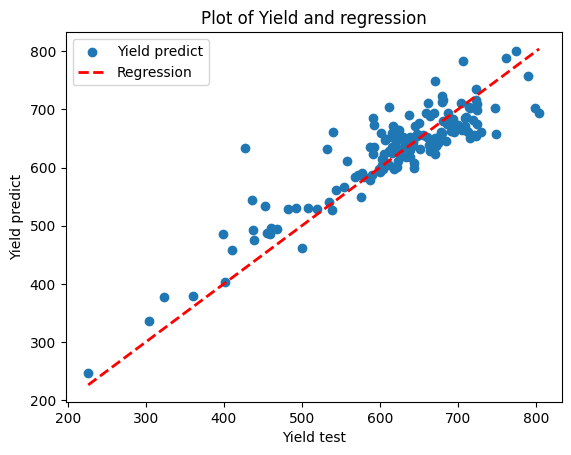

In [8]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

In [9]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
#metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [10]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 427.0, 'predict': 633.2636699218878, 'error': 0.48305309115196193},
 {'truth': 436.0, 'predict': 543.3669314430393, 'error': 0.24625442991522783},
 {'truth': 540.0, 'predict': 661.7024224969082, 'error': 0.2253748564757559},
 {'truth': 398.2896,
  'predict': 484.9398051625741,
  'error': 0.21755578142782056},
 {'truth': 532.0, 'predict': 631.3785902084131, 'error': 0.18680186129400964},
 {'truth': 453.0, 'predict': 534.0540399858432, 'error': 0.17892724058685044},
 {'truth': 322.9881,
  'predict': 377.58589685295385,
  'error': 0.16903965456607808},
 {'truth': 590.605,
  'predict': 685.4461516621393,
  'error': 0.16058304901268916},
 {'truth': 612.0, 'predict': 703.7248168611478, 'error': 0.14987715173390165},
 {'truth': 592.0, 'predict': 673.2776047052977, 'error': 0.13729325119138122},
 {'truth': 804.0, 'predict': 694.289440110592, 'error': 0.13645592026045777},
 {'truth': 437.0, 'predict': 492.05145988893963, 'error': 0.12597588075272226},
 {'truth': 749.0, 'predict': 657